# 按子图拆分分组

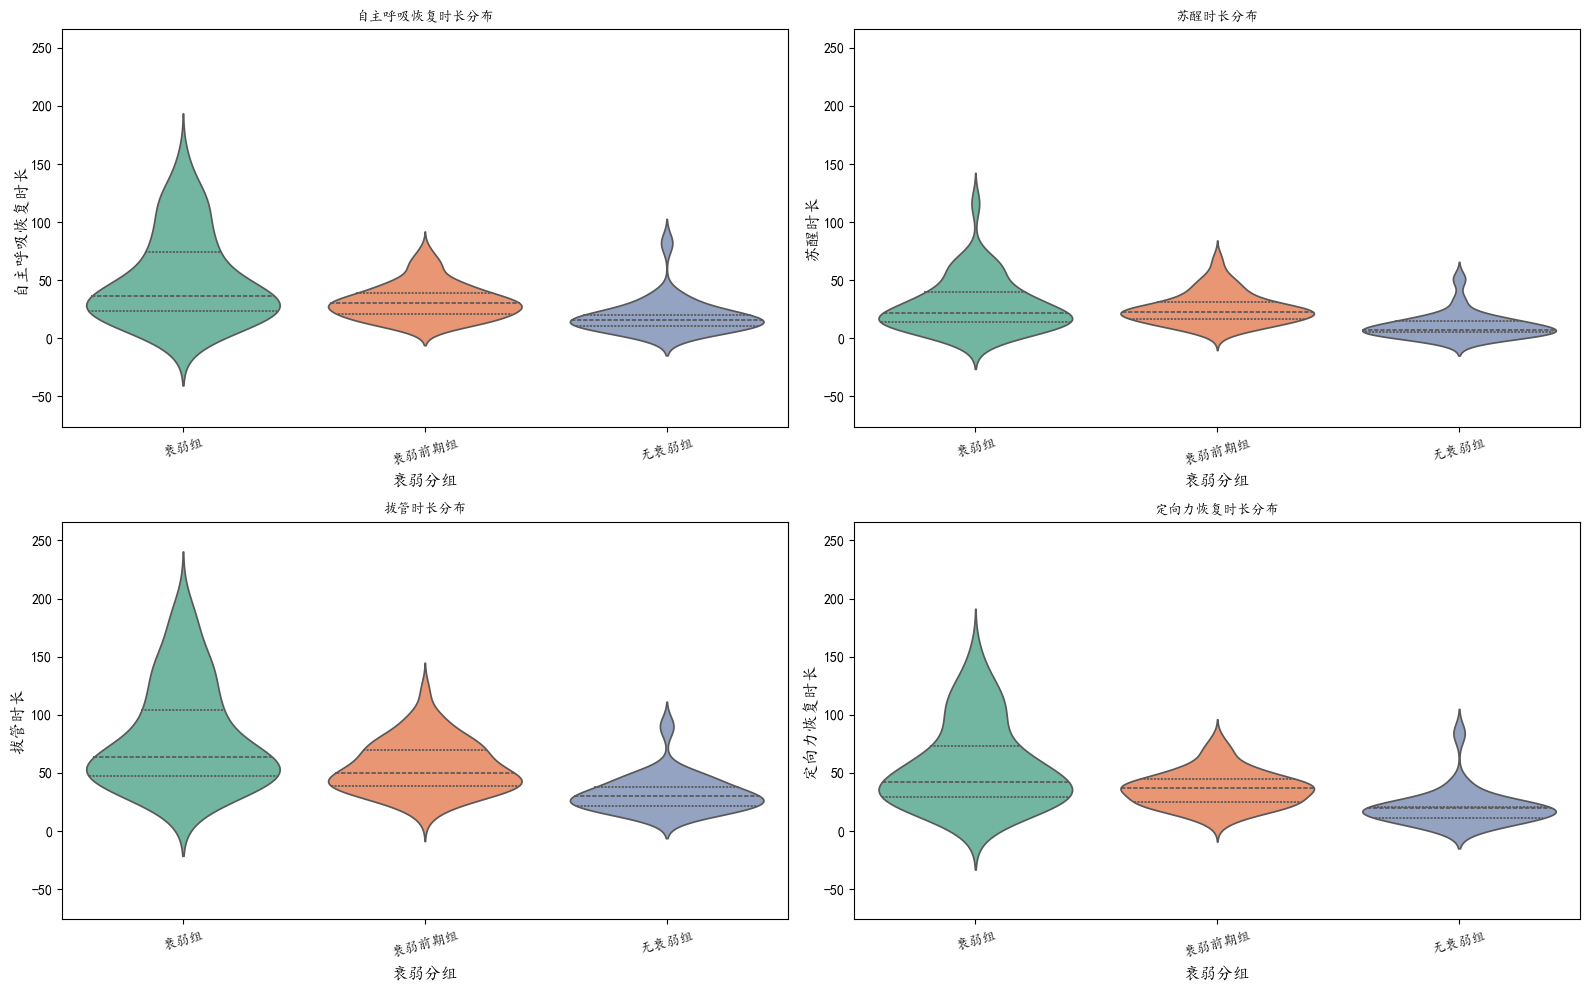

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
 
# 设置字体路径
font_path = r'../simkai.ttf'  # Windows示例
 
# 加载字体并设置
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
 
# 读取数据
data = pd.read_csv('复苏时长.csv')
 
# 分组函数
def group_frailty_score(score):
    if score == 0:
        return '无衰弱组'
    elif 1 <= score <= 2:
        return '衰弱前期组'
    elif 3 <= score <= 4:
        return '衰弱组'
 
data['衰弱分组'] = data['衰弱评分'].apply(group_frailty_score)
 
# 指标列表
metrics = ['自主呼吸恢复时长', '苏醒时长', '拔管时长', '定向力恢复时长']
 
# 计算全局y轴范围（添加5%缓冲）
global_min = min(data[metric].min() for metric in metrics)
global_max = max(data[metric].max() for metric in metrics)
buffer = 0.4 * (global_max - global_min)
y_lim = (global_min - buffer, global_max + buffer)
 
# 绘图
plt.figure(figsize=(16, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.violinplot(
        x='衰弱分组',
        y=metric,
        data=data,
        hue='衰弱分组',
        palette='Set2',
        inner='quartile',
        legend=False,
        cut=2.5
    )
    # 设置统一y轴范围
    plt.ylim(y_lim)
    # 显式设置字体
    plt.title(f'{metric}分布', fontsize=14, fontproperties=font_prop)
    plt.xlabel('衰弱分组', fontsize=12, fontproperties=font_prop)
    plt.ylabel(metric, fontsize=12, fontproperties=font_prop)
    plt.xticks(rotation=15)
 
plt.tight_layout()
plt.savefig('按子图拆分分组.png', dpi=400, bbox_inches='tight')
plt.show()